# Session 17- Intro to NN - Part 2

Activation functions introduce non-linearity into neural networks, allowing them to learn complex patterns and decision boundaries. They transform a neuron's weighted sum output and determine how much information is passed to the next layer. Functions like ReLU can also suppress weak activations by outputting zero, which indirectly helps focus on useful features.

Z = ΣX.W + b

a = F(Z)

-----

Dense Layer = Fully Connected

Number of input features = Number of input neurons

--------------

| Problem Type                              | Output Neurons    | Activation    |
| ----------------------------------------- | ----------------- | ------------- |
| Binary Classification                     | 1                 | Sigmoid       |
| Multi-Class Classification (Cat/Dog/Goat) | Number of classes | Softmax       |
| Regression (one value)                    | 1                 | Linear / None |
| Multi-Output Regression                   | Number of targets | Linear / None |


------

MLP and CNN are feedforward networks where information flows only from input to output. RNNs, LSTMs, and GRUs have recurrent connections that pass hidden states across time steps, giving them memory of previous inputs.

------

A 28×28 image can be flattened into a 784-dimensional vector for fully connected networks (MLP), but in modern deep learning (CNNs in PyTorch/TensorFlow), it is kept in its 2D spatial form so the model can learn local patterns like edges and shapes using convolution filters.

-----

Neural networks train in two main stages: forward propagation, where inputs pass through the network to produce a prediction, and backpropagation, where the error is computed and gradients are calculated using the chain rule to update weights via gradient descent. Backpropagation is the key learning mechanism.

--------------

A derivative tells how the loss changes when we change a weight or bias

The derivative in backpropagation measures how much a small change in a parameter (weight or bias) affects the loss. Using the chain rule, we break the computation into small steps: first how loss changes with output, then how output changes with parameters. For example, the derivative of output with respect to bias is 1 because bias adds directly to the output, while derivative with respect to weight is the input x because weight scales the input.

----

Gradient descent iteratively updates weights in the opposite direction of the gradient to minimize loss. The gradient's sign tells us the direction, the learning rate controls step size, and we stop when the gradient approaches zero

-----------
## Summary :

In machine learning, the derivative measures how the loss changes with respect to model parameters, telling us the direction and magnitude of adjustment needed. Gradient descent uses these derivatives to iteratively update weights in the opposite direction of the gradient to minimize the loss function.

based on the Formula :

w_new = w_old - η × (∂Loss/∂w)

if Gradient is Pos(+) the w_new will be decreased  (consider (-old) - (-)  = more (-) means decreasing)) and ( (+old) - (+) still decreasing

if Gradient is Neg(-) the w_new will be increased

both approaches help get better loss and minimize the loss


----------


Neural networks are highly parallel because they consist of large numbers of independent matrix and vector operations. GPUs are designed with thousands of small cores optimized for parallel numerical computation, allowing them to perform these operations simultaneously. CPUs, in contrast, have fewer powerful cores optimized for sequential and complex logic tasks, making them slower for large-scale neural network training. Therefore, GPUs significantly accelerate both forward and backward propagation

---------

Backpropagation in a multi-layer neural network is based on the chain rule of calculus, where the gradient of the loss with respect to each weight is computed by propagating errors backward layer by layer. The error at each layer is calculated as the product of the gradient from the next layer, the transposed weight matrix, and the derivative of the activation function. Each weight is then updated using gradient descent by subtracting the learning rate multiplied by its gradient.

----------

Vanishing gradient occurs in deep neural networks when gradients shrink exponentially during backpropagation due to repeated multiplication of derivatives less than one, especially with sigmoid or tanh activations. This causes early layers to receive very small updates and learn slowly or not at all. It is different from overfitting, which is when a model memorizes training data instead of generalizing. Vanishing gradient leads to underfitting or poor learning in deep layers.

leading to underfitting or poor representation learning

-----

Overfitting in neural networks occurs when the model learns not only the underlying patterns but also noise in the training data. It is mainly caused by high model complexity, insufficient training data, lack of regularization techniques like dropout or L2 regularization, excessive training epochs, and low data diversity. As a result, the model performs well on training data but poorly on unseen test data.

-----------

Representation learning is the process by which a neural network automatically learns useful feature representations from raw data. Lower layers learn simple patterns, while deeper layers learn increasingly abstract and meaningful features that help solve the task

-----

Take batch

↓

Forward

↓

Loss

↓

Backward

↓

Update

↓

Get NEXT batch

-------------

During training, the model performs a forward pass, computes the loss, performs backpropagation, and updates the weights for each batch. In SGD, weights are updated after every sample. In Batch Gradient Descent, weights are updated once per epoch using the entire dataset. In Mini-Batch Gradient Descent, weights are updated once per mini-batch. The number of updates equals the number of batches per epoch multiplied by the number of epochs.

---------

Polynomial Regression and Neural Networks both increase model capacity to learn more complex relationships. Polynomial Regression does this by explicitly adding higher-order terms such as x
^2
,x
^3
, and x
^4
, while Neural Networks increase capacity through additional neurons, layers, and nonlinear activation functions. However, polynomial regression relies on manually defined features, whereas neural networks automatically learn hierarchical feature representations from raw data

------

Polynomial regression is like teaching one subject 100 times, while neural networks teach 100 new points.

-----

How do you choose depth and width in a neural network?


There is no universal rule. Increasing width (neurons) is often tried before significantly increasing depth because deeper networks are harder to train and require more data. However, some tasks require depth to learn hierarchical representations. Hidden layers are often arranged in a gradually decreasing funnel shape to compress information, but this is a design choice rather than a strict requirement.

## Class Material

In [1]:
import numpy as np
#Mnist
from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

data = fetch_openml(name="mnist_784")

In [2]:
import pandas as pd
df = pd.DataFrame(data.data, columns=data.feature_names)
X  = df
y = data.target
print(X)
print(y)

       pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
0           0       0       0       0       0       0       0       0       0   
1           0       0       0       0       0       0       0       0       0   
2           0       0       0       0       0       0       0       0       0   
3           0       0       0       0       0       0       0       0       0   
4           0       0       0       0       0       0       0       0       0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
69995       0       0       0       0       0       0       0       0       0   
69996       0       0       0       0       0       0       0       0       0   
69997       0       0       0       0       0       0       0       0       0   
69998       0       0       0       0       0       0       0       0       0   
69999       0       0       0       0       0       0       0       0       0   

       pixel10  ...  pixel7

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
from sklearn.metrics import classification_report
model = MLPClassifier(
    hidden_layer_sizes=(32,32),
    activation="relu",
    solver="adam",
    max_iter=20,
    verbose=True,
    early_stopping=True,
)

#params = {"hidden_layer_sizes" :[(32,32) ,  (64,64), (128,128,32,8) , (32,32, 32, 8)]}

#grid_model = GridSearchCV(model, param_grid=params, cv=5, n_jobs=-1)

#grid_model.fit(X_train, y_train)

#best_model = grid_model.best_estimator_

model.fit(X_train, y_train)

y_pred=model.predict(X_test)



Iteration 1, loss = 3.04568752
Iteration 2, loss = 0.89422614
Iteration 3, loss = 0.64714611
Iteration 4, loss = 0.52464122
Iteration 5, loss = 0.44966073
Iteration 6, loss = 0.40046271
Iteration 7, loss = 0.36621990
Iteration 8, loss = 0.34162669
Iteration 9, loss = 0.31693879
Iteration 10, loss = 0.29069333
Iteration 11, loss = 0.27568625
Iteration 12, loss = 0.25658935
Iteration 13, loss = 0.24603843
Iteration 14, loss = 0.23823099
Iteration 15, loss = 0.22510853
Iteration 16, loss = 0.21607739
Iteration 17, loss = 0.20417075
Iteration 18, loss = 0.20757671
Iteration 19, loss = 0.19241637
Iteration 20, loss = 0.18594264
Iteration 21, loss = 0.17884007
Iteration 22, loss = 0.17629686
Iteration 23, loss = 0.17032141
Iteration 24, loss = 0.16732272
Iteration 25, loss = 0.15812080
Iteration 26, loss = 0.15089006
Iteration 27, loss = 0.15346280
Iteration 28, loss = 0.14935810
Iteration 29, loss = 0.14117398
Iteration 30, loss = 0.13786699
Iteration 31, loss = 0.14026605
Iteration 32, los

In [16]:
import numpy as np
np.unique(y, return_counts=True)

(array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object),
 array([6903, 7877, 6990, 7141, 6824, 6313, 6876, 7293, 6825, 6958]))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1343
           1       0.98      0.98      0.98      1600
           2       0.94      0.92      0.93      1380
           3       0.93      0.92      0.93      1433
           4       0.94      0.94      0.94      1295
           5       0.93      0.93      0.93      1273
           6       0.96      0.97      0.97      1396
           7       0.95      0.95      0.95      1503
           8       0.91      0.90      0.91      1357
           9       0.92      0.93      0.92      1420

    accuracy                           0.94     14000
   macro avg       0.94      0.94      0.94     14000
weighted avg       0.94      0.94      0.94     14000



<Axes: >

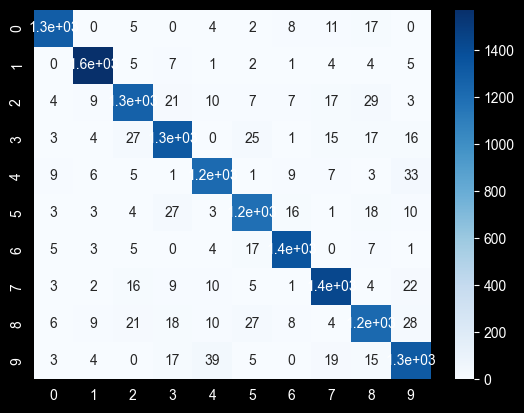

In [14]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import  seaborn as sns
classification_report = classification_report(y_test, y_pred)
print(classification_report)
cm=confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True,cmap="Blues")

In [3]:
# TensorFlow Keras
from tensorflow.keras import models, layers
model = models.Sequential([
    layers.Input(shape=(5,)),

    layers.Dense(50, activation='relu'),
    layers.Dense(50, activation='relu'),
    layers.Dense(50, activation='relu'),
    layers.Dense(50, activation='relu'),
    layers.Dense(50, activation='relu'),
    layers.Dense(50, activation='relu'),
    layers.Dense(50, activation='relu'),
    layers.Dense(50, activation='relu'),

    layers.Dense(3, activation='softmax'),
])

print(model.summary())


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 50)                300       
                                                                 
 dense_1 (Dense)             (None, 50)                2550      
                                                                 
 dense_2 (Dense)             (None, 50)                2550      
                                                                 
 dense_3 (Dense)             (None, 50)                2550      
                                                                 
 dense_4 (Dense)             (None, 50)                2550      
                                                                 
 dense_5 (Dense)             (None, 50)                2550      
                                                                 
 dense_6 (Dense)             (None, 50)                

1.26.4


## BTC_prediction (direction )

As project Done in another file

In [ ]:
## Chapter 10 ML book

In [ ]:
# this is called TLU - threshold logic unit :
# here we used heaviside function as step function
# other step function is sign : >0 1/ =0 0/ <0 -1
y = np.array([0, 0, 0, 1])


def step_function(z):
    return 1 if z > 0 else 0


max_iter = 30
m = len(X)

w = np.random.randn(2)
b = 0
lr = 0.1


for epoch in range(max_iter):

    indices = np.random.permutation(m)

    X_shuffle = X[indices]
    y_shuffle = y[indices]

    for i in range(m):

        x = X_shuffle[i]
        target = y_shuffle[i]

        # Forward pass
        z = np.dot(x, w) + b
        y_pred = step_function(z)

        # Error
        err = target - y_pred

        # Update
        w = w + lr * err * x
        b = b + lr * err


print("w:", w)
print("b:", b)

for x in X:
    z = np.dot(w, x) + b
    prediction = step_function(z)
    print(x, "->", prediction)


In [ ]:
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.metrics import classification_report
X,y = load_iris(return_X_y=True)
tlu = Perceptron()
tlu.fit(X, y)
y_pred=tlu.predict(X)
print(classification_report(y, y_pred))


In [ ]:
## MLP Regreesion

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
#%%
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
X_train_full, y_train_full, random_state=42)
#%%
mlp_reg = MLPRegressor(hidden_layer_sizes=(50,50,50),random_state=42,)
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", mlp_reg)
])
pipeline.fit(X_train, y_train)
#%%
y_pred = pipeline.predict(X_valid)
rmse = np.square(mean_squared_error(y_valid, y_pred))
print(rmse)

## MLP Classification

In [ ]:
from sklearn.datasets import load_iris
from sklearn.neural_network import MLPClassifier
X,y = load_iris(return_X_y=True)
#%%
model = MLPClassifier(hidden_layer_sizes=(50,50,50),random_state=42,max_iter=300)
model.fit(X, y)
#%%
y_ped = model.predict(X)
#%%
from sklearn.metrics import classification_report
print(classification_report(y, y_ped))

In [ ]:
## Implementing MLPs with Keras
Keras used to support multiple backends, including TensorFlow,
PlaidML, Theano, and Microsoft Cognitive Toolkit (CNTK) (the
last two are sadly deprecated), but since version 2.4, Keras is
TensorFlow-only. Similarly, TensorFlow used to include multiple
high-level APIs, but Keras was officially chosen as its preferred
high-level API when TensorFlow 2 came out. Installing TensorFlow
will automatically install Keras as well, and Keras will not work
without TensorFlow installed. In short, Keras and TensorFlow fell
in love and got married. Other popular deep learning libraries
include PyTorch by Facebook and JAX by Google.1